In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [ ]:

df_auto = pd.read_csv(
    "automation_data_by_state.csv", encoding="latin1"
)
df_salary = pd.read_excel("occupation_salary.xlsx")
df_abilities = pd.read_csv("abilities.csv")
df_skills = pd.read_csv("essential_skills.csv")

target_abilities = ["Originality", "Manual Dexterity"]
ab_sub = df_abilities[
    (df_abilities["Element Name"].isin(target_abilities))
    & (df_abilities["Scale ID"] == "LV")
]
ab_pivot = ab_sub.pivot_table(
    index="O*NET-SOC Code",
    columns="Element Name",
    values="Data Value",
    aggfunc="mean",
).reset_index()

target_skills = [
    "Social Perceptiveness",
    "Complex Problem Solving",
    "Critical Thinking",
]
sk_sub = df_skills[
    (df_skills["Element Name"].isin(target_skills))
    & (df_skills["Scale ID"] == "LV")
]
sk_pivot = sk_sub.pivot_table(
    index="O*NET-SOC Code",
    columns="Element Name",
    values="Data Value",
    aggfunc="mean",
).reset_index()

onet_features = pd.merge(ab_pivot, sk_pivot, on="O*NET-SOC Code", how="inner")

df_auto["match_code"] = (
    df_auto["SOC"].astype(str).str.split(".").str[0].str.strip()
)
df_salary["match_code"] = (
    df_salary["OCC_CODE"].astype(str).str.split(".").str[0].str.strip()
)
onet_features["match_code"] = (
    onet_features["O*NET-SOC Code"]
    .astype(str)
    .str.split(".")
    .str[0]
    .str.strip()
)

df_merged = pd.merge(
    df_auto, df_salary, on="match_code", how="inner"
)
df_merged = pd.merge(
    df_merged, onet_features, on="match_code", how="inner"
)

output_path = "merged_raw_dataset.csv"
df_merged.to_csv(output_path, index=False)

print(f"merge in\n{output_path}")
print(f"rows: {len(df_merged)}")

print(f"columns: {df_merged.shape[1]}")

merge in
D:\Nti\ai risk data\merged_raw_dataset.csv
rows: 709
columns: 79


In [ ]:
df = pd.read_csv("merged_raw_dataset.csv")

selected_cols = {
    "SOC": "soc_code",
    "Occupation": "job_title",
    "Probability": "automation_risk",
    "A_MEAN": "annual_mean_salary",
    "TOT_EMP": "total_employment",
    "Originality": "creativity_level",
    "Manual Dexterity": "manual_dexterity",
    "Critical Thinking": "critical_thinking",
}

clean_df = df[list(selected_cols.keys())].rename(columns=selected_cols).copy()

clean_df["annual_mean_salary"] = pd.to_numeric(
    clean_df["annual_mean_salary"].astype(str).str.replace(",", ""),
    errors="coerce",
)
clean_df["total_employment"] = pd.to_numeric(
    clean_df["total_employment"].astype(str).str.replace(",", ""),
    errors="coerce",
)
clean_df["automation_risk"] = pd.to_numeric(
    clean_df["automation_risk"], errors="coerce"
)

clean_df = (
    clean_df.groupby(["soc_code", "job_title"], as_index=False)
    .agg({
        "automation_risk": "first",
        "annual_mean_salary": "first",
        "total_employment": "first",
        "creativity_level": "mean",
        "manual_dexterity": "mean",
        "critical_thinking": "mean",
    })
    .dropna()
)

final_path = "final_clean_academic_dataset.csv"
clean_df.to_csv(final_path, index=False)

print(f"saving dataset successfully\n{final_path}")
print(f"number of unique jobs: {len(clean_df)}")
print(clean_df.head())

saving dataset successfully
final_clean_academic_dataset.csv
number of unique jobs: 614
  soc_code                            job_title  automation_risk  \
0  11-1011                     Chief Executives            0.015   
1  11-1021      General and Operations Managers            0.160   
2  11-2011  Advertising and Promotions Managers            0.039   
3  11-2021                   Marketing Managers            0.014   
4  11-2022                       Sales Managers            0.013   

   annual_mean_salary  total_employment  creativity_level  manual_dexterity  \
0            194350.0            223260             4.125              0.00   
1            122090.0           2188870             3.500              0.50   
2            117810.0             28860             4.000              0.38   
3            144140.0            205900             4.000              0.38   
4            135090.0            365230             3.880              0.38   

   critical_thinking  
0    

In [ ]:
df = pd.read_csv("final_clean_ai_risk_dataset.csv")

In [7]:
df.head()

,soc_code,job_title,automation_risk,annual_mean_salary,total_employment,creativity_level,manual_dexterity,critical_thinking
0,11-1011,Chief Executives,0.015,194350.0,223260,4.125,0.00,4.435
1,11-1021,General and Operations Managers,0.160,122090.0,2188870,3.500,0.50,3.880
2,11-2011,Advertising and Promotions Managers,0.039,117810.0,28860,4.000,0.38,4.120
3,11-2021,Marketing Managers,0.014,144140.0,205900,4.000,0.38,4.120
4,11-2022,Sales Managers,0.013,135090.0,365230,3.880,0.38,4.000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   soc_code            614 non-null    str    
 1   job_title           614 non-null    str    
 2   automation_risk     614 non-null    float64
 3   annual_mean_salary  614 non-null    float64
 4   total_employment    614 non-null    int64  
 5   creativity_level    614 non-null    float64
 6   manual_dexterity    614 non-null    float64
 7   critical_thinking   614 non-null    float64
dtypes: float64(5), int64(1), str(2)
memory usage: 63.0 KB


In [9]:
df.isna().sum()

soc_code              0
job_title             0
automation_risk       0
annual_mean_salary    0
total_employment      0
creativity_level      0
manual_dexterity      0
critical_thinking     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,automation_risk,annual_mean_salary,total_employment,creativity_level,manual_dexterity,critical_thinking
count,614.000000,614.000000,6.140000e+02,614.000000,614.000000,614.000000
mean,0.544851,55393.289902,1.785473e+05,2.729120,2.221899,3.445389
std,0.370701,28921.836807,4.110915e+05,0.790053,1.152820,0.655933
min,0.002800,20570.000000,3.700000e+02,0.620000,0.000000,1.620000
25%,0.110000,35357.500000,1.730750e+04,2.000000,1.380000,3.000000
50%,0.655000,47425.000000,4.784500e+04,2.750000,2.750000,3.380000
75%,0.900000,66477.500000,1.454450e+05,3.250000,3.120000,4.000000
max,0.990000,232870.000000,4.528550e+06,5.500000,5.250000,5.750000


In [12]:
df.columns

Index(['soc_code', 'job_title', 'automation_risk', 'annual_mean_salary',
       'total_employment', 'creativity_level', 'manual_dexterity',
       'critical_thinking'],
      dtype='str')

In [13]:
numCols = df.select_dtypes(include=np.number).columns

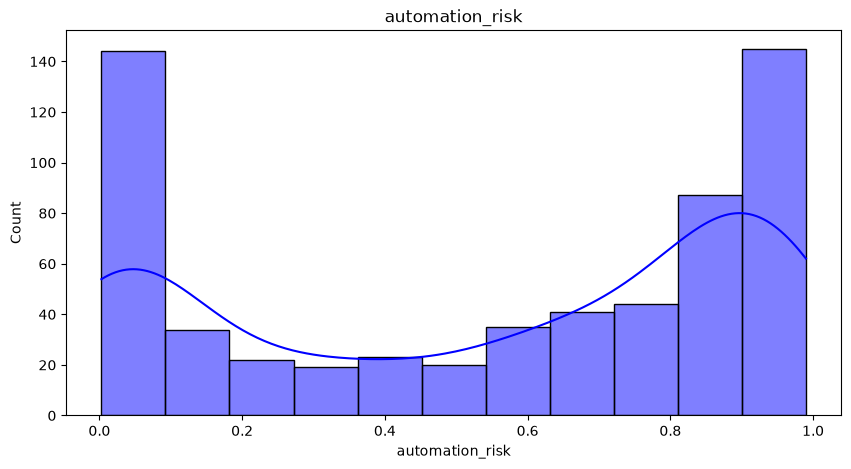

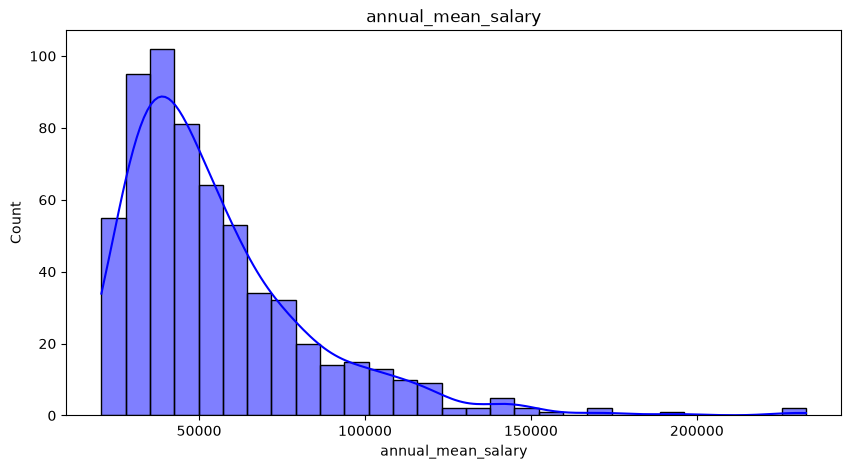

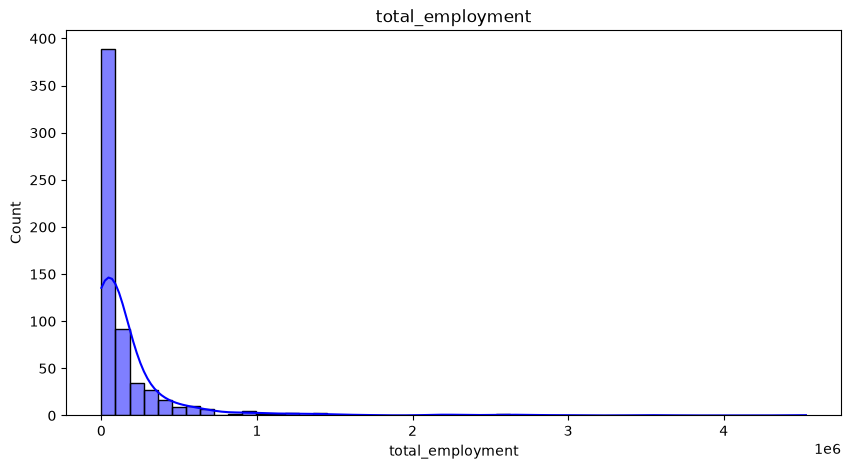

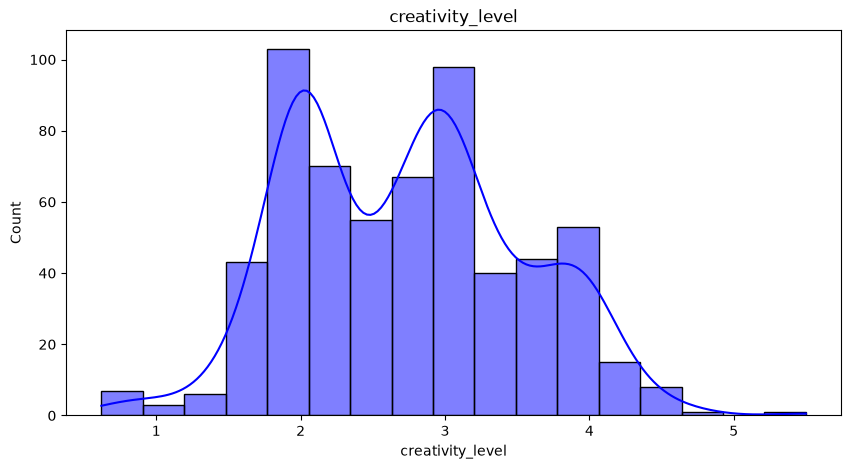

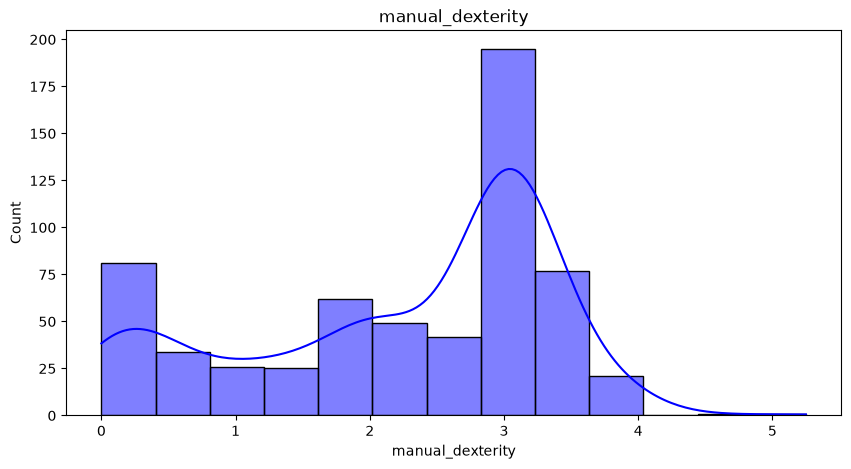

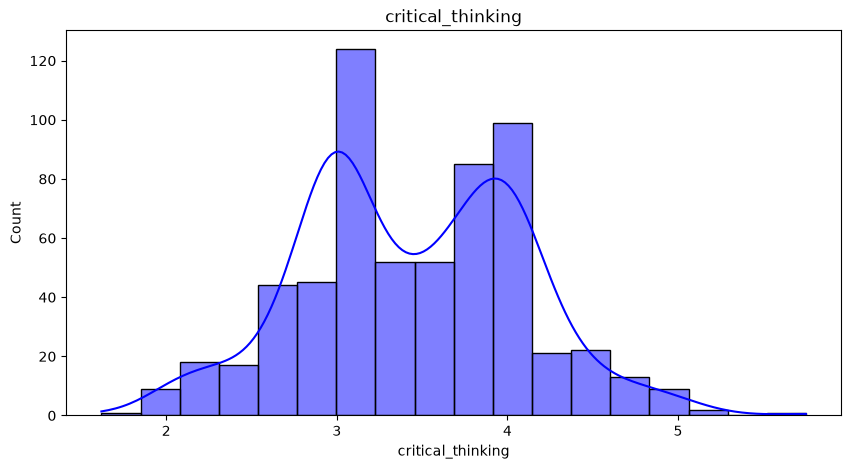

In [14]:
for col in numCols :
  plt.figure(figsize = (10,5))
  plt.title(col)
  sns.histplot(data = df, x = col, color = 'Blue', kde = True)
  plt.show()

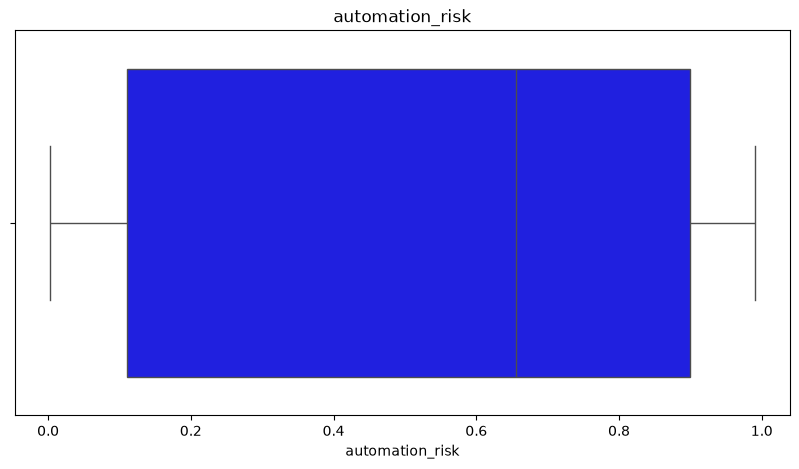

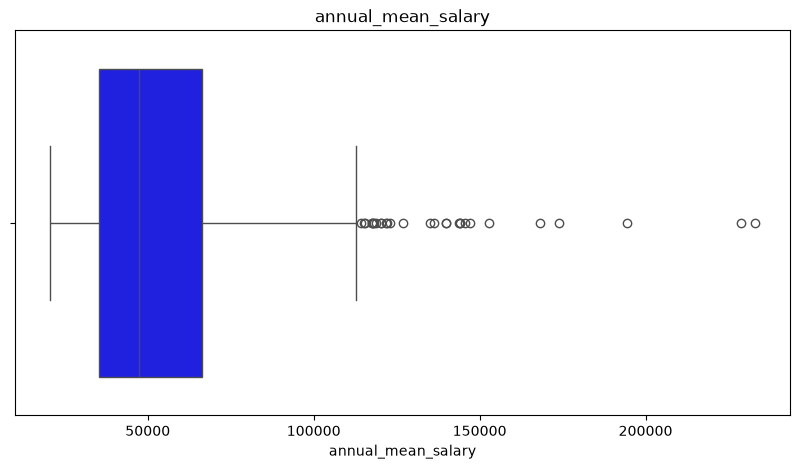

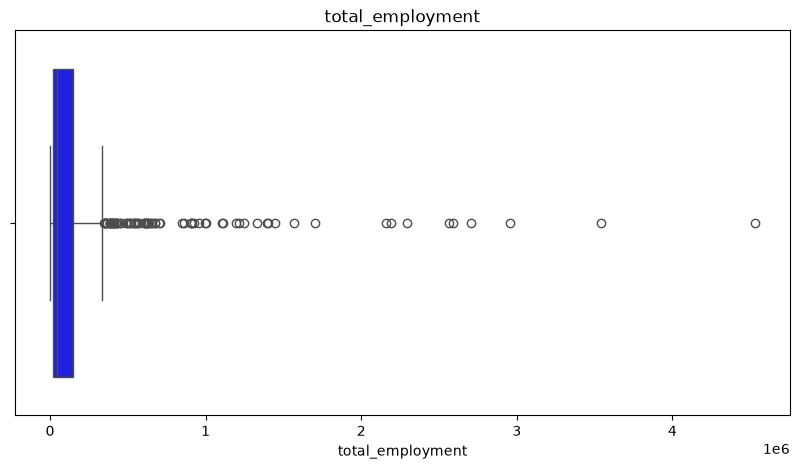

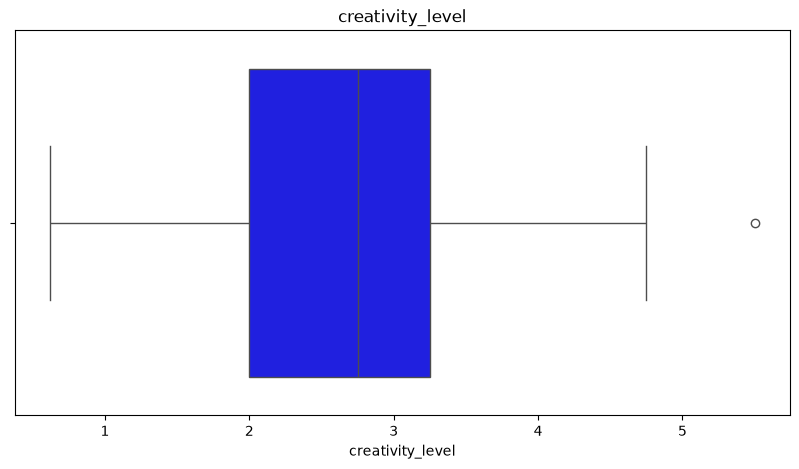

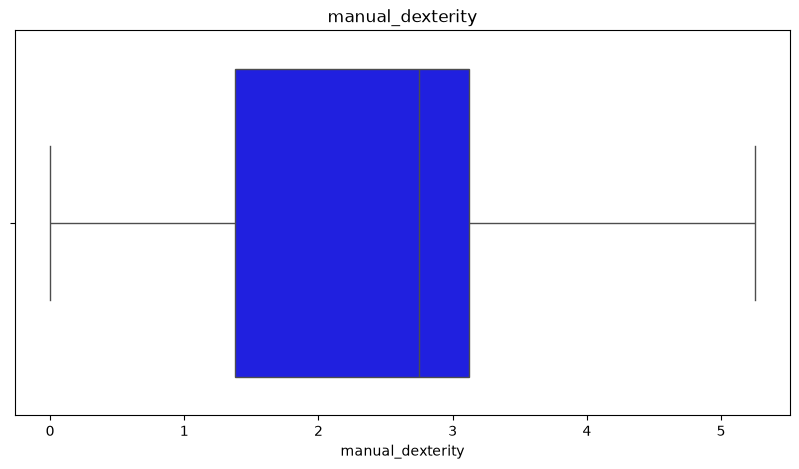

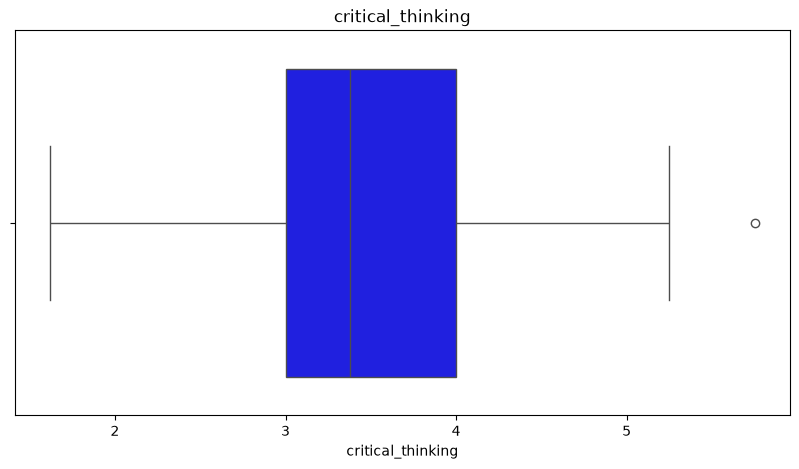

In [15]:
for col in numCols :
  plt.figure(figsize = (10,5))
  plt.title(col)
  sns.boxplot(data = df, x = col, color = 'Blue')
  plt.show()

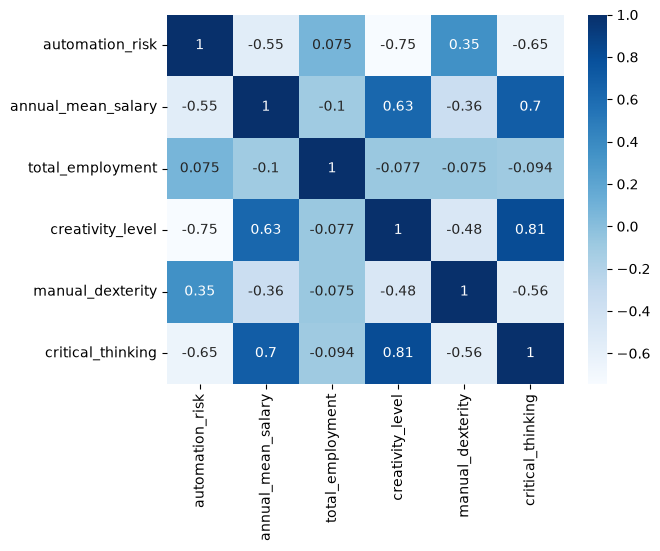

In [16]:
correlation_matrix = df[numCols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='Blues')

plt.show()


In [17]:
df["soc_major_group"] = pd.to_numeric(
    df["soc_code"].astype(str).str[:2], errors="coerce"
)

df["soc_major_group"] = df["soc_major_group"].fillna(0).astype(int)

print("Major groups count:", df["soc_major_group"].nunique())

df = pd.get_dummies(
    df, columns=["soc_major_group"], prefix="major", drop_first=True
)

major_cols = [c for c in df.columns if c.startswith("major_")]
print(f"Major Groups created: {len(major_cols)}")
print(major_cols)

Major groups count: 22
Major Groups created: 21
['major_13', 'major_15', 'major_17', 'major_19', 'major_21', 'major_23', 'major_25', 'major_27', 'major_29', 'major_31', 'major_33', 'major_35', 'major_37', 'major_39', 'major_41', 'major_43', 'major_45', 'major_47', 'major_49', 'major_51', 'major_53']


In [18]:
df.head()

,soc_code,job_title,automation_risk,annual_mean_salary,total_employment,creativity_level,manual_dexterity,critical_thinking,major_13,major_15,...,major_35,major_37,major_39,major_41,major_43,major_45,major_47,major_49,major_51,major_53
0,11-1011,Chief Executives,0.015,194350.0,223260,4.125,0.00,4.435,False,False,...,False,False,False,False,False,False,False,False,False,False
1,11-1021,General and Operations Managers,0.160,122090.0,2188870,3.500,0.50,3.880,False,False,...,False,False,False,False,False,False,False,False,False,False
2,11-2011,Advertising and Promotions Managers,0.039,117810.0,28860,4.000,0.38,4.120,False,False,...,False,False,False,False,False,False,False,False,False,False
3,11-2021,Marketing Managers,0.014,144140.0,205900,4.000,0.38,4.120,False,False,...,False,False,False,False,False,False,False,False,False,False
4,11-2022,Sales Managers,0.013,135090.0,365230,3.880,0.38,4.000,False,False,...,False,False,False,False,False,False,False,False,False,False


In [19]:
df.select_dtypes("number").columns.to_list()

['automation_risk',
 'annual_mean_salary',
 'total_employment',
 'creativity_level',
 'manual_dexterity',
 'critical_thinking']

SKEW AND OUTLIERS

In [20]:
numeric_cols = df.select_dtypes("number").columns.to_list()

for col in numeric_cols:
    print(
        f"{col}: "
        f"skewness = {df[col].skew():.2f}"
    )

automation_risk: skewness = -0.33
annual_mean_salary: skewness = 1.94
total_employment: skewness = 5.51
creativity_level: skewness = 0.19
manual_dexterity: skewness = -0.64
critical_thinking: skewness = 0.06


In [21]:
df['total_employment_log'] = np.log1p(df['total_employment'])

df['annual_mean_salary_log'] = np.log1p(
    df['annual_mean_salary']
)

print("Salary:")
print("Before:", df['annual_mean_salary'].skew())
print("After :", df['annual_mean_salary_log'].skew())

print("\nEmployment:")
print("Before:", df['total_employment'].skew())
print("After :", df['total_employment_log'].skew())

Salary:
Before: 1.9411629405896091
After : 0.47641469532740965

Employment:
Before: 5.5105143967951795
After : 0.05235508634465008


In [22]:
features = [

    "annual_mean_salary_log",
    "total_employment_log",
    "manual_dexterity",
    "creativity_level",
    "critical_thinking",

     *major_cols

]


x = df[features]

y = df['automation_risk']

In [23]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,

)

In [24]:
print("X_train:", x_train.shape)
print("x_test :", x_test.shape)


X_train: (491, 26)
x_test : (123, 26)


In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [26]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

In [27]:
def train_evaluate(model,x_train,x_test,y_train,y_test):

  model.fit(x_train,y_train)

  y_pred = model.predict(x_test)
  y_pred_train = model.predict(x_train)



  test_mae = mean_absolute_error(y_test, y_pred)


  test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))


  test_r2 = r2_score(y_test, y_pred)




  train_mae = mean_absolute_error(y_train,y_pred_train)

  train_rmse = np.sqrt(mean_squared_error(y_train ,y_pred_train))


  train_r2 = r2_score(y_train, y_pred_train)
  return {
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    }



In [28]:
models_results = {}

In [29]:
lr= Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
models_results["linear Regression"]=train_evaluate(lr,x_train,x_test,y_train,y_test)

In [30]:
svr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR())
])
models_results["SVR"]=train_evaluate(svr,x_train,x_test,y_train,y_test)

In [31]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor())
])
models_results["knn"]=train_evaluate(knn,x_train,x_test,y_train,y_test)

In [32]:
from sklearn.tree import DecisionTreeRegressor

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42
)

models_results["Decision Tree"] = train_evaluate(
    dt, x_train, x_test, y_train, y_test
)

models_results["Decision Tree"]=train_evaluate(dt,x_train,x_test,y_train,y_test)

In [33]:
rf = RandomForestRegressor(random_state=42)
models_results["RandomForest"]=train_evaluate(rf,x_train,x_test,y_train,y_test)

In [34]:
gb = GradientBoostingRegressor(random_state=42)
models_results["gb"]=train_evaluate(gb,x_train,x_test,y_train,y_test)

In [35]:
results_df = pd.DataFrame(models_results).T

results_df = results_df.sort_values(
    by="Test R2",
    ascending=False
)

results_df

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
gb,0.093762,0.125966,0.125129,0.176028,0.883623,0.788321
RandomForest,0.056014,0.131291,0.076187,0.181114,0.956857,0.775910
Decision Tree,0.124525,0.126191,0.174573,0.185831,0.773481,0.764087
SVR,0.128900,0.151483,0.169156,0.195710,0.787320,0.738337
linear Regression,0.166444,0.173483,0.214323,0.221047,0.658582,0.666200
knn,0.146613,0.164151,0.201474,0.229206,0.698291,0.641104


RF VS GB VS SVR

In [37]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

best_rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
)
best_rf.fit(x_train, y_train)
print(f"RF Train R²: {best_rf.score(x_train, y_train):.4f}")
print(f"RF Test R²:  {best_rf.score(x_test, y_test):.4f}")


gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
}
gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_params,
    cv=5,
    scoring="r2",
    n_jobs=1,
)
gb_grid.fit(x_train, y_train)
best_gb = gb_grid.best_estimator_
print(f"Best GB CV R²: {gb_grid.best_score_:.4f}")

svr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR())
])
svr_params = {
    "model__C": [1, 10, 100],
    "model__gamma": ["scale", "auto"],
    "model__epsilon": [0.01, 0.1],
}
svr_grid = GridSearchCV(
    estimator=svr_pipe,
    param_grid=svr_params,
    cv=5,
    scoring="r2",
    n_jobs=1,
)
svr_grid.fit(x_train, y_train)
best_svr = svr_grid.best_estimator_
print(f"Best SVR CV R²: {svr_grid.best_score_:.4f}")

RF Train R²: 0.9194
RF Test R²:  0.7965
Best GB CV R²: 0.7155
Best SVR CV R²: 0.6804


In [38]:
rf_result = train_evaluate(best_rf, x_train, x_test, y_train, y_test)
gb_result = train_evaluate(best_gb, x_train, x_test, y_train, y_test)
svr_result = train_evaluate(best_svr, x_train, x_test, y_train, y_test)

print("--- Final Model Comparison ---")
print("Random Forest:", rf_result)
print("Gradient Boosting:", gb_result)
print("SVR:", svr_result)

--- Final Model Comparison ---
Random Forest: {'Train MAE': 0.07821314564452243, 'Test MAE': 0.12762979208730463, 'Train RMSE': np.float64(0.10411594851838649), 'Test RMSE': np.float64(0.17259475914355735), 'Train R2': 0.9194280106962881, 'Test R2': 0.7964964970884479}
Gradient Boosting: {'Train MAE': 0.11614555171940338, 'Test MAE': 0.1302384275755733, 'Train RMSE': np.float64(0.1514158874926344), 'Test RMSE': np.float64(0.1756762246355208), 'Train R2': 0.8295910269355046, 'Test R2': 0.7891650233698295}
SVR: {'Train MAE': 0.12890028507560425, 'Test MAE': 0.15148267090810108, 'Train RMSE': np.float64(0.16915647326260536), 'Test RMSE': np.float64(0.195709775522749), 'Train R2': 0.7873199222628776, 'Test R2': 0.7383373602554404}


In [39]:
import joblib

joblib.dump(best_rf, r"D:\Nti\ai risk data\real_model.pkl")
print("Model successfully saved to D:\\Nti\\ai risk data\\real_model.pkl")

Model successfully saved to D:\Nti\ai risk data\real_model.pkl


In [40]:
import pandas as pd

df_export = x.copy()

job_col_name = None
for c in ['Job Title', 'title', 'job_title', 'occupation', 'Occupation', 'Title']:
  if c in df.columns:
    job_col_name = c
    break

if job_col_name:
  df_export['Job Title'] = df.loc[x.index, job_col_name].values
else:
  df_export['Job Title'] = [f'Job #{i}' for i in range(len(x))]

df_export['predicted_risk'] = best_rf.predict(x)
df_export['risk_pct'] = (df_export['predicted_risk'] * 100).round(1)


def get_risk_label(val):
  if val >= 70.0:
    return '🔴 High Risk'
  elif val >= 35.0:
    return '🟡 Medium Risk'
  else:
    return '🟢 Low Risk'


df_export['risk_level'] = df_export['risk_pct'].apply(get_risk_label)

for c in ['annual_mean_salary', 'total_employment']:
  if c in df.columns:
    df_export[c] = df.loc[x.index, c].values

df_export.to_csv(r'D:\Nti\ai risk data\predicted_jobs.csv', index=False)
print('Exported successfully! Class distribution:')
print(df_export['risk_level'].value_counts())

Exported successfully! Class distribution:
risk_level
🔴 High Risk      292
🟢 Low Risk       201
🟡 Medium Risk    121
Name: count, dtype: int64


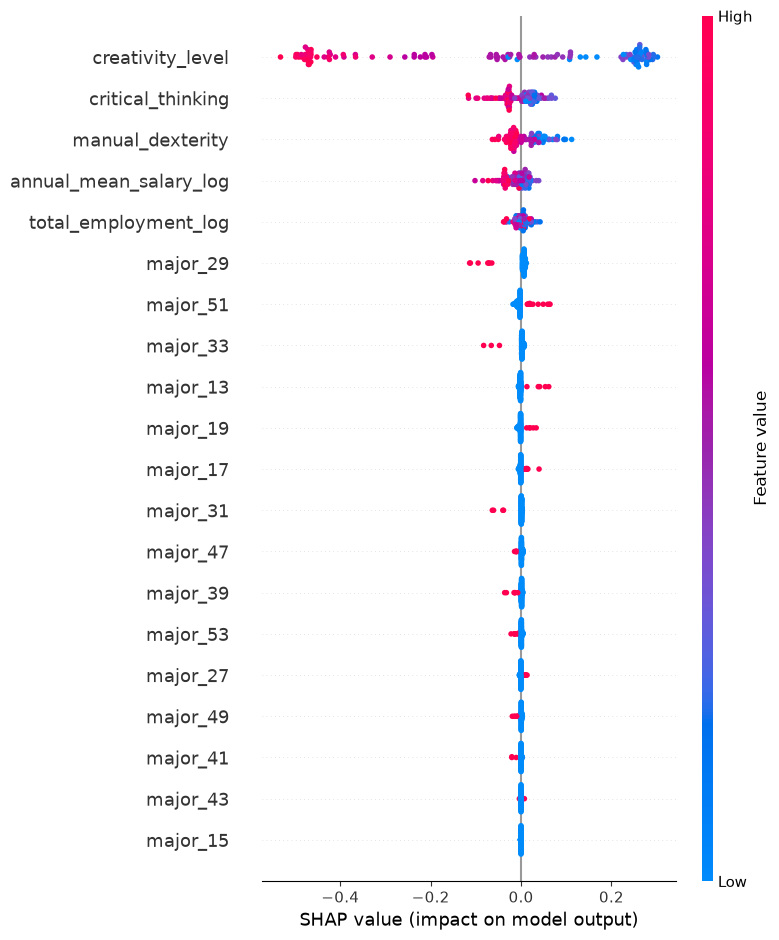

In [41]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer(x_test)

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, x_test, show=True)
plt.close()

In [42]:
import joblib

joblib.dump(best_rf, r"D:\Nti\ai risk data\real_model.pkl")

print("Model successfully saved to D:\\Nti\\ai risk data\\real_model.pkl")

Model successfully saved to D:\Nti\ai risk data\real_model.pkl
